* * *
<pre> NYU Paris            <i> Machine Learning - Sumer 2023 </i></pre>
* * *


<h1 align="center"> Lab Unsupervised learning: clustering </h1>

<pre align="left"> June 08th 2023               <i> Author: Guillaume Staerman </i></pre>
* * *


##### Goals:
- More practice with numpy and matplotlib
- Understand the pros and cons of K-means clustering, hierarchical clustering and GMM

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

seed = 42

# Part 1: Implementing K-means

In the past labs, we have mainly seen:
- dimension reduction (with PCA)
- classification (i.e supervised learning)

In practice however, the vast majority of data does not have labels. Finding structure and patterns in data without labels is called unsupervised learning. Given a specified number of clusters K, the K-means algorithm forms a partition of your data with K different groups while trying to:
- minimize the variance within groups (i.e samples forming a group must be close to each other)
- maximize the variance between groups (i.e groups must be far from each other).

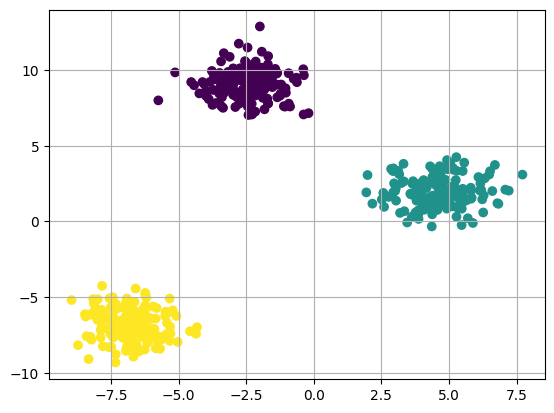

In [2]:
from sklearn.datasets import make_blobs

X, y = make_blobs(500, centers=3, n_features=2, cluster_std=1., random_state=seed)

plt.figure()
plt.grid()
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()


It is called K-means because it only consists of two steps. Starting from an initialization of K mean values $M_k$:
- For each sample $x$ of your data, find the mean (centroid) $C_k$ that is closest to x. Assign $x$ to group $k$.
- Update the mean $C_k$ of each group k

### Question 1
Write a function that generates K random initializations for the group centroids $C_k$.

In [3]:
import numpy as np

def init_centroids(K, dimension=2):
    centroids = np.random.rand(K, dimension)
    return centroids

### Question 2
Write a function that takes the data X (n, d) and returns an array (n,) containing the id of the cluster it should be assigned to. For example, the function returns [0, 0, 2, 1, 2] if the first two samples are assigned to cluster 0, the 3rd and 5th samples to cluster 2 and the 4th sample to cluster 1.

_Hint: look up `sklearn.metrics.pairwise_distances` and the numpy method of an array `array.argmin`_

In [4]:
from sklearn.metrics import pairwise_distances

def assign_labels(X, centroids):
    distances = pairwise_distances(X, centroids)
    labels = np.argmin(distances, axis=1)
    return labels

### Question 3
The following cell visualizes the centroids and their assigned samples. Initialize the centroids and compute a first set of labels of your data and visualize them. Can you think of a smarter way to initialize these centroids using the data? (No need to implement it for now).

In [5]:
def plot_kmeans(X, labels, centroids):
    K = len(centroids)
    colors = np.array(cm.Set1(np.linspace(0., 1, K)))
    plt.figure()
    plt.grid()
    plt.scatter(X[:, 0], X[:, 1], color=colors[labels], s=4, alpha=0.3)
    plt.scatter(centroids[:, 0], centroids[:, 1], color=colors, marker="^", s=100)
    plt.show()


### Question 4
Write a function that computes the new centroids using the assigned labels. Visualize the new centroids. Repeat these steps (label assignment + centroid update) for 2-3 steps. Does it converge?

In [6]:
def update_centroids(X, labels, centroids):
    for i in range(centroids.shape[0]):
        assigned_points = X[labels == i]
        if len(assigned_points) > 0:
            centroids[i] = np.mean(X[labels == i], axis=0)
    return centroids

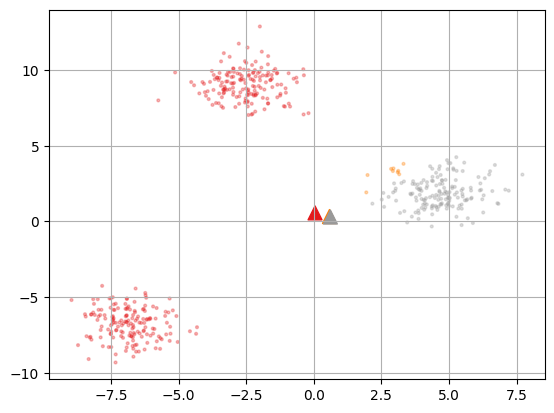

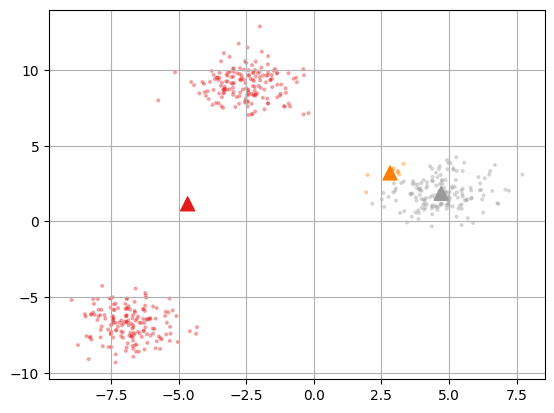

[[-4.66580165  1.16288758]
 [ 2.81984544  3.19944112]
 [ 4.71637057  1.85963546]]


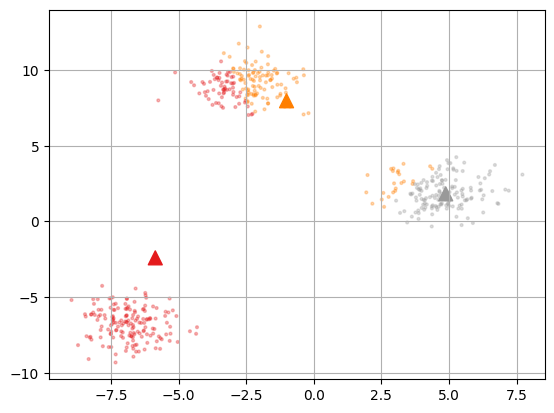

[[-5.86267124 -2.39992173]
 [-1.00699386  7.96491862]
 [ 4.88119924  1.82280498]]


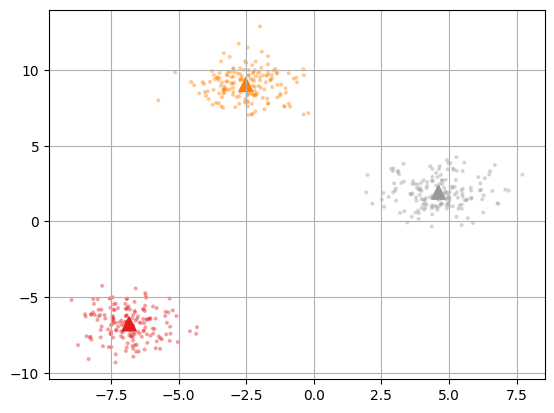

[[-6.83120002 -6.75657544]
 [-2.51336974  9.03492867]
 [ 4.61416263  1.93184055]]


In [7]:
centroids = init_centroids(K = 3, dimension=2)
labels = assign_labels(X, centroids)
plot_kmeans(X, labels, centroids)
for _ in range(3):
    labels = assign_labels(X, centroids)
    centroids = update_centroids(X, labels, centroids)
    plot_kmeans(X, labels, centroids)
    print(centroids)

The alogrithem does converges.

### Question 5
The K-means algorithm repeats these operations until the centroids stop changing. Write a function summing up all these operations.

In [8]:
def Kmeans(X, K=3, maxiter=100, plot_steps=False):
    dimension = X.shape[1]
    centroids = init_centroids(K, dimension)
    for ii in range(maxiter):
        old_centroids = centroids.copy()
        labels = assign_labels(X, centroids)
        new_centroids = update_centroids(X, labels, centroids)
        if plot_steps:
            plot_kmeans(X, labels, centroids)
        if np.array_equal(old_centroids, new_centroids):
            break
        centroids = new_centroids
    return labels, centroids


### Question 6

Generate different sets of data examples (changing the `cluster_std` parameter) and visualize the K-means output. What do you notice?

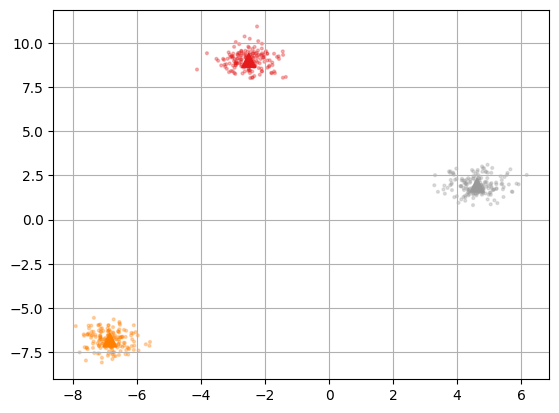

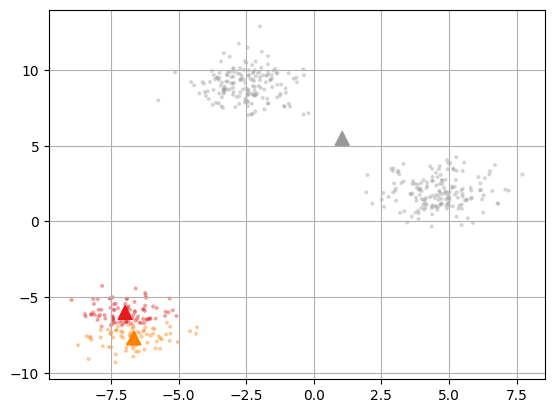

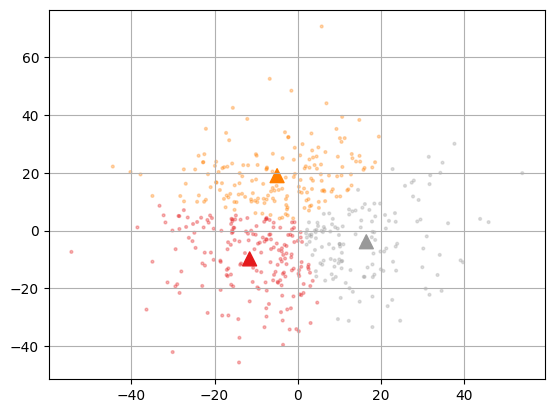

In [9]:
from sklearn.datasets import make_blobs

cluster_stds = [0.5,1,16]

for std in cluster_stds:
    X, _ = make_blobs(n_samples=500, centers=3, cluster_std=std, random_state=42)
    labels, centroids = Kmeans(X, K=3)
    plot_kmeans(X,labels,centroids)

The standard deviation of the clusters increases, the clusters become less distinct and it becomes harder for the K-means algorithm to correctly identify the clusters.

### Question 7
Try Kmeans with this new data. Choose K wisely. Is it normal that Kmeans fails?

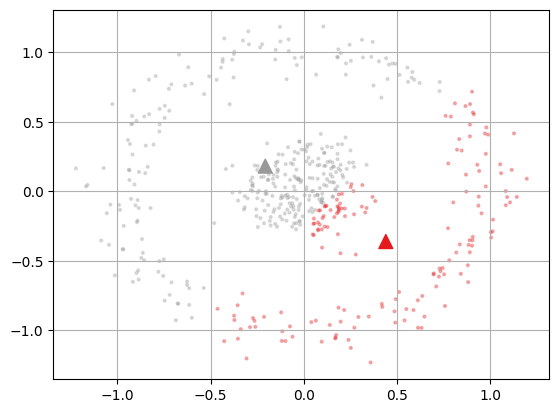

In [10]:
from sklearn.datasets import make_circles

X, y = make_circles(500, noise=0.1, factor=0.2)

labels, centroids = Kmeans(X, K=2)
plot_kmeans(X, labels, centroids)

If we see the outer circles as out liers, then kmean clustering is not suitable for this case. We should use a algorithm that can cluster by the distance to center, or the weight. Maybe DBSCAN is good for this senario.

# Part 2: Compressing images with K-means
Is it often the case that data is redundant. Take the example of the image below:

Image original shape:  (427, 640, 3)
Flower colors shape:  (273280, 3)


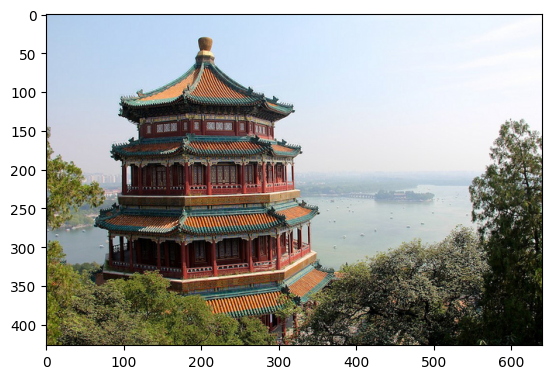

In [11]:
from sklearn.datasets import load_sample_image

flower = load_sample_image('china.jpg') / 255
flower_shape = flower.shape
flower_colors = flower.reshape(-1, 3)

print("Image original shape: ", flower_shape)
print("Flower colors shape: ", flower_colors.shape)

max_color = flower.max()

plt.figure()
plt.imshow(flower)
plt.show()

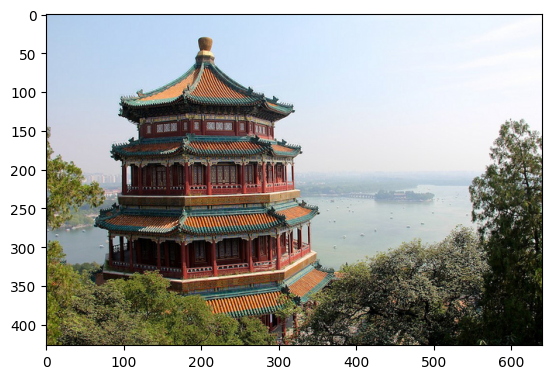

In [12]:
plt.imshow(flower)

### Question 8
We would like to replace all colors by replacing them with the centroid they're closest to. Let's for example reduce them to 16. Run the Kmeans algorithm with K=16 on the downsampled colors array X. Then create a new image with the replaced colors and visualize it.

In [13]:
flower_colors.shape

(273280, 3)

Text(0.5, 1.0, '16-color Image')

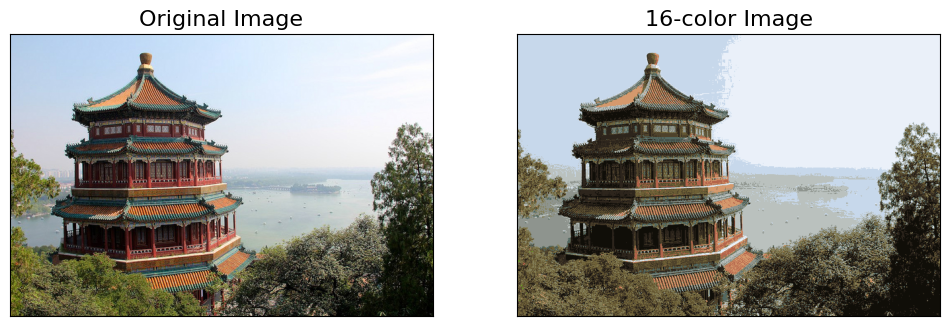

In [14]:
from sklearn.utils import shuffle
from sklearn.cluster import KMeans
X = shuffle(flower_colors, random_state=0, n_samples=1_000)
labels, centroids = Kmeans(X, K=16, maxiter=100, plot_steps=False)
all_labels = assign_labels(flower_colors, centroids)
new_image_0 = centroids[all_labels].reshape(flower_shape)
fig, ax = plt.subplots(1, 2, figsize=(12, 6),subplot_kw=dict(xticks=[], yticks=[]))
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(new_image_0)
ax[1].set_title('16-color Image', size=16)


In [15]:
flower_colors

array([[0.68235294, 0.78823529, 0.90588235],
       [0.68235294, 0.78823529, 0.90588235],
       [0.68235294, 0.78823529, 0.90588235],
       ...,
       [0.16862745, 0.19215686, 0.15294118],
       [0.05098039, 0.08235294, 0.02352941],
       [0.05882353, 0.09411765, 0.02745098]])

### Question 9
Play around with the value of n_clusters (K). What do you notice?

Text(0.5, 1.0, '64-color Image')

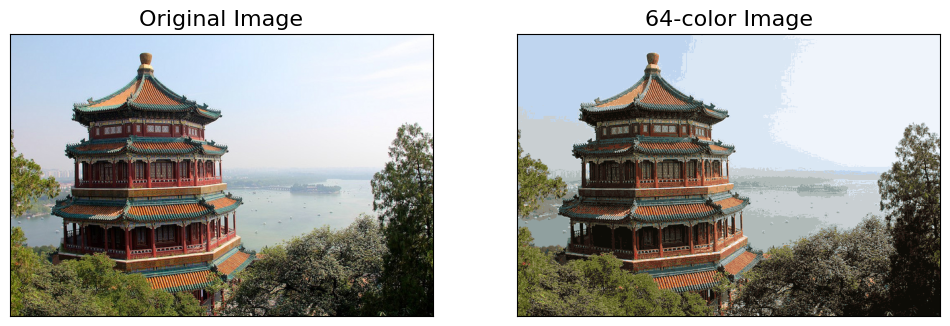

In [16]:
labels, centroids = Kmeans(X, K=64, maxiter=100, plot_steps=False)
all_labels = assign_labels(flower_colors, centroids)
new_image = centroids[all_labels].reshape(flower_shape)
fig, ax = plt.subplots(1, 2, figsize=(12, 6),subplot_kw=dict(xticks=[], yticks=[]))
ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(new_image)
ax[1].set_title('64-color Image', size=16)

K is the number of colors exhibited in the image.

### Question 10
Try this out but using the sklearn implementation of Kmeans. Do you obtain similar results? Can you explain the difference?

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


Text(0.5, 1.0, '16-color Image with SKlearn Kmean')

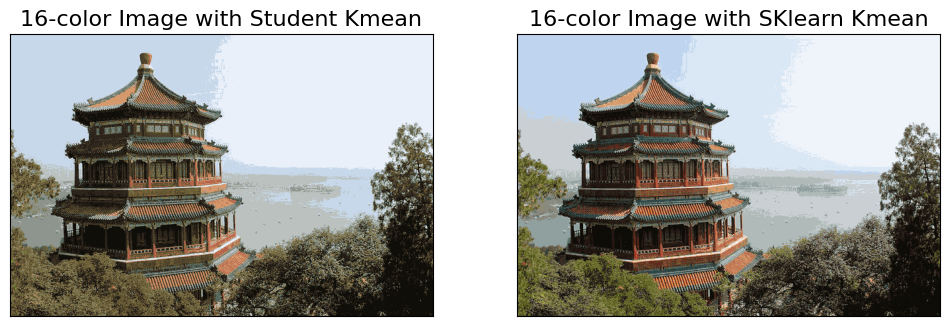

In [17]:
kmeans = KMeans(n_clusters=16, random_state=0, init='k-means++').fit(X)
labels = kmeans.predict(X)
all_labels = assign_labels(flower_colors, centroids)
new_image = centroids[all_labels].reshape(flower_shape)
new_colors = kmeans.cluster_centers_[labels].astype(int)
fig, ax = plt.subplots(1, 2, figsize=(12, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
ax[0].imshow(new_image_0)
ax[0].set_title('16-color Image with Student Kmean', size=16)
ax[1].imshow(new_image)
ax[1].set_title('16-color Image with SKlearn Kmean', size=16)

There is no significant difference in the result. The major difference is the selection of inital centroids. If SKlearn choose Kmean ++,

# Part 3: Implementing  Hierarchical clustering


## Question 11

Implement a function that compute the distance matrix between data. The parameter 'distance' define the chosen distance on the Euclidean space. You can use functions from scipy or sklearn. Implement three distances of your choice.

In [18]:
from scipy.spatial import distance_matrix
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances, cosine_distances

def distance_matrix(X, distance='euclidean'):
    if distance == 'euclidean':
        matrix = euclidean_distances(X)
    elif distance == 'manhattan':
        matrix = manhattan_distances(X)
    elif distance == 'cosine':
        matrix = cosine_distances(X)
    else:
        raise ValueError(f'Unknown distance: {distance}')
    return matrix

## Question 12

Implement diffent similarity functions between clusters that you have seen in class (Linkage slide). Regarding the question 13, find a clever way to implement cluster variable (cluster1, cluster2).

In [19]:
def cluster_similarity(cluster1, cluster2, X, matrix_distance, linkage, distance='euclidean'):
    if linkage == 'single':
        return matrix_distance[cluster1][:, cluster2].min()
    elif linkage == 'complete':
        return matrix_distance[cluster1][:, cluster2].max()
    elif linkage == 'centroid':
        centroid1 = X[cluster1].mean(axis=0)
        centroid2 = X[cluster2].mean(axis=0)
        return np.linalg.norm(centroid1 - centroid2)
    elif linkage == 'average':
        return matrix_distance[cluster1][:, cluster2].mean()
    else:
        raise ValueError(f'Unknown linkage: {linkage}')

## Question 13

Implement a function that performs Agglomerative Hierarchical Clustering.

In [20]:
from scipy.cluster.hierarchy import linkage, fcluster

def agglo_hier_clust(X, linkage_method):
    Z = linkage(X, method=linkage_method)
    clusters = fcluster(Z, t=1.0, criterion='distance')

    return clusters

## Question 14 (Bonus)

Implement a function that performs Divisive Hierarchical Clustering.

In [21]:
def divisive_hier_clust(X, linkage, threshold):
    clusters = [list(range(len(X)))]
    while max([len(cluster) for cluster in clusters]) > threshold:
        largest_cluster = max(clusters, key=len)
        clusters.remove(largest_cluster)
        kmeans = KMeans(n_clusters=2, random_state=0).fit(X[largest_cluster])
        labels = kmeans.labels_
        clusters.append([point for point, label in zip(largest_cluster, labels) if label == 0])
        clusters.append([point for point, label in zip(largest_cluster, labels) if label == 1])
    cluster_ids = np.empty(len(X), dtype=int)
    for cluster_id, cluster in enumerate(clusters):
        cluster_ids[cluster] = cluster_id
    return cluster_ids

## Question 15

Apply this (or these) algorithm(s) on the Gaussian blobs

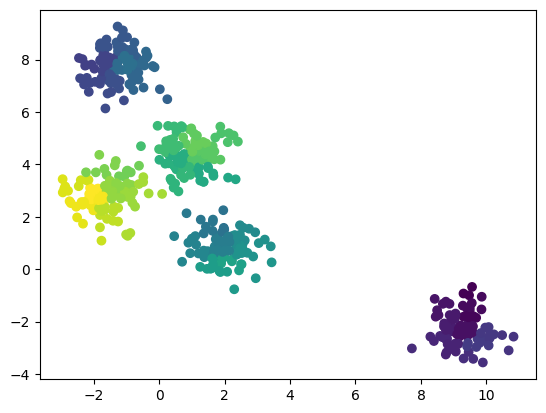

In [22]:
from sklearn.datasets import make_blobs

# Generate Gaussian blobs
X, y = make_blobs(n_samples=500, centers=5, random_state=0, cluster_std=0.60)

# Perform agglomerative hierarchical clustering
agglo_clusters = agglo_hier_clust(X, 'ward')

# Plot the clusters
plt.scatter(X[:, 0], X[:, 1], c=agglo_clusters, cmap='viridis')

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


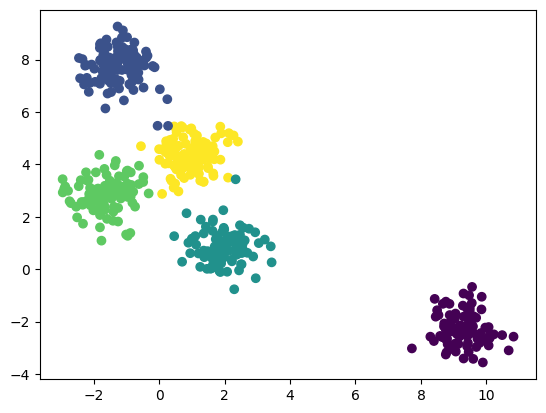

In [23]:
# Perform agglomerative hierarchical clustering
divisive_hier_clusters = divisive_hier_clust(X, 'ward',150)

# Plot the clusters
plt.scatter(X[:, 0], X[:, 1], c=divisive_hier_clusters, cmap='viridis')

## Question 16

Use now the scipy implementation of the hierarchical clustering algorithm and visualize the associated dendrogram. How many clusters should you choose inspecting the dendrogram? According to this number of cluster, compute the accuracy of the algorithm

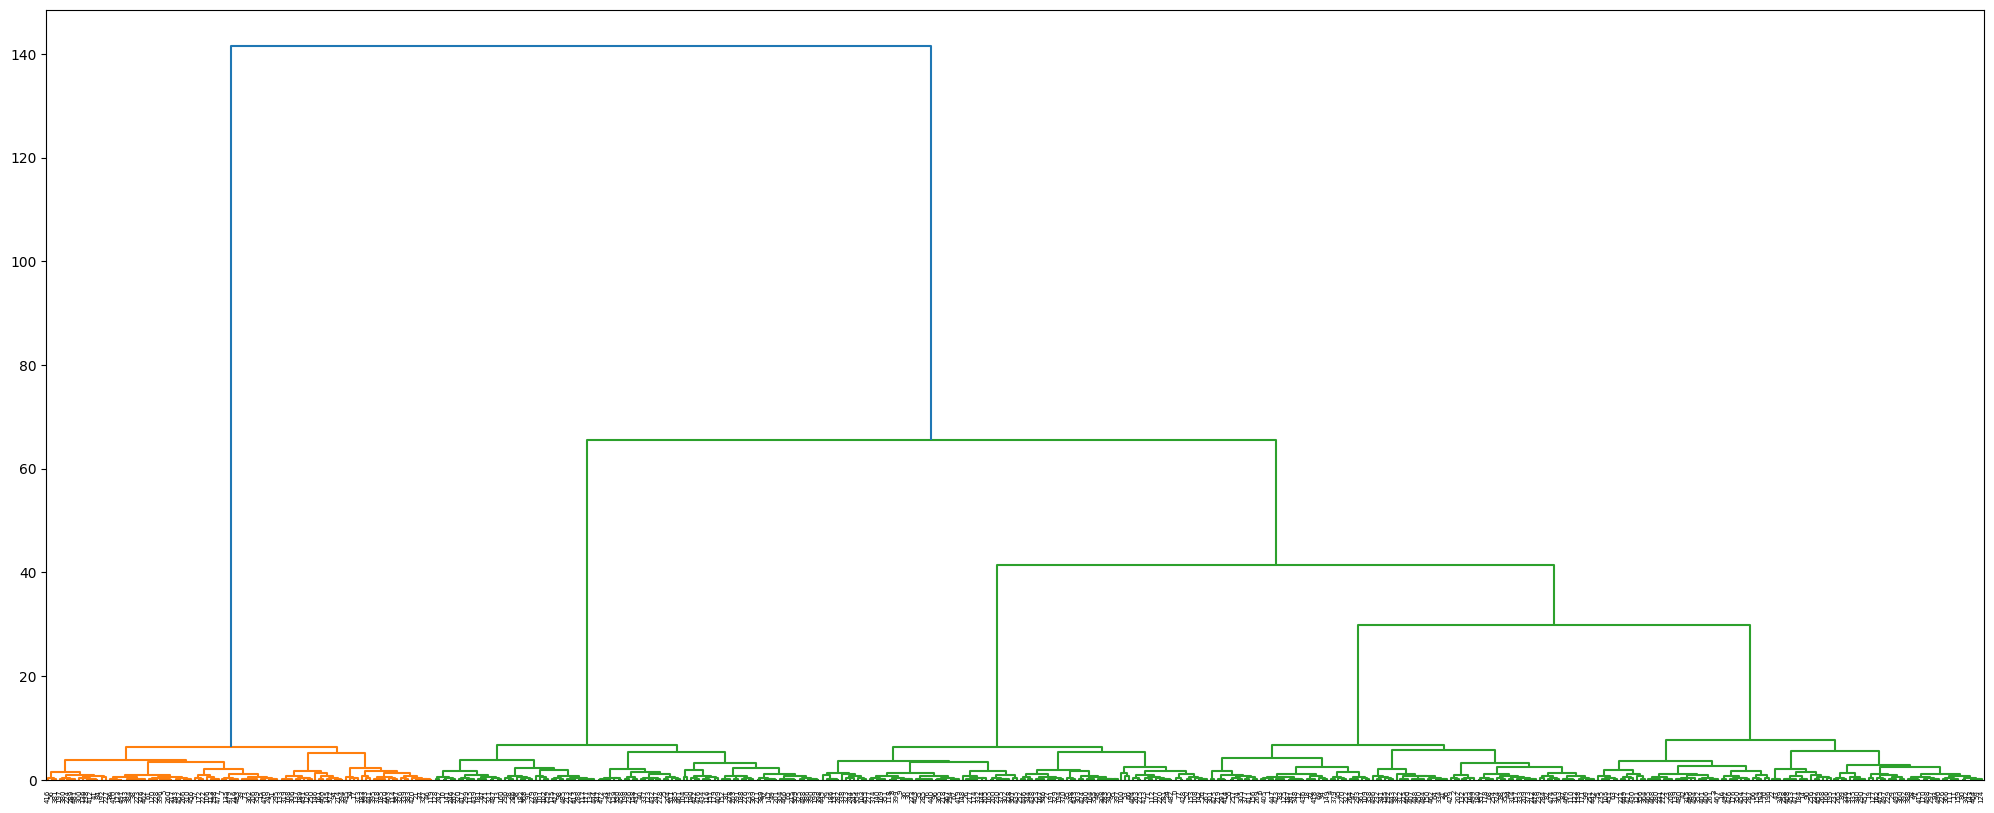

In [24]:
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(X, 'ward')
plt.figure(figsize=(25, 10))
dendrogram(Z)
plt.show()

# Part 4: Clustering Algorithms Comparison

## Question 17

- Import three images datasets as we did in previous labs: MNIST, FashionMNIST and CIFAR10. Vectorize these images to have vector input data.

In [25]:
import torch
from torchvision import datasets, transforms
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
mnist = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=True,transform=transform)
fashion_mnist = datasets.FashionMNIST('~/.pytorch/FashionMNIST_data/', download=True, train=True, transform=transform)
cifar10 = datasets.CIFAR10('~/.pytorch/CIFAR10_data/', download=True, train=True, transform=transform)

X_mnist = mnist.data.numpy().reshape((len(mnist), -1))
y_mnist = mnist.targets.numpy()

X_fashion = fashion_mnist.data.numpy().reshape((len(fashion_mnist), -1))
y_fashion = fashion_mnist.targets.numpy()

X_cifar = cifar10.data.reshape((len(cifar10), -1))
y_cifar = np.array(cifar10.targets)

Files already downloaded and verified


## Question 18

- Perform K-means, Hierarchical clustering and Model-based algorithms (GMM) (you all have seen these algorithms in class). You can use these algorithms from sklearn.

NB: use images of these datasets to perform clustering, keep the labels only to assign performances of your algorithms.

In [26]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(X_mnist[:5000])
kmeans_labels = kmeans.labels_
agglo = AgglomerativeClustering(n_clusters=n_clusters).fit(X_mnist[:5000])
agglo_labels = agglo.labels_
gmm = GaussianMixture(n_components=n_clusters).fit(X_mnist[:5000])
gmm_labels = gmm.predict(X_mnist[:5000])

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


## Question 19

Asses the performance of each algorithm.

On each dataset, describe what you observe. Overall, is there any algorithms that is better? If yes, why?

In [27]:
kmeans_accuracy = accuracy_score(y_mnist[:5000], kmeans_labels)
agglo_accuracy = accuracy_score(y_mnist[:5000], agglo_labels)
gmm_accuracy = accuracy_score(y_mnist[:5000], gmm_labels)

print(f'K-means accuracy: {kmeans_accuracy}')
print(f'Agglomerative clustering accuracy: {agglo_accuracy}')
print(f'GMM accuracy: {gmm_accuracy}')

K-means accuracy: 0.084
Agglomerative clustering accuracy: 0.1356
GMM accuracy: 0.1744


## Question 20

List pros and cons of each algorithms from what you have seen during the lab.

K-means++:

Pros:
Simple and easy to implement.
Efficient in terms of computational cost.
Works well with spherical clusters and large datasets.

Cons:
Assumes clusters are convex and isotropic, which is not always the case.
The number of clusters (K) needs to be set beforehand.
Sensitive to initial centroids, although K-means++ improves this with a smarter initialization.

Agglomerative Clustering:

Pros:
Does not require the number of clusters to be specified.
Can produce a hierarchy of clusters, which is useful for multilevel data.
Can work with different distance metrics and linkage criteria.

Cons:
Computationally expensive, especially for large datasets.
The result can be sensitive to the choice of linkage method.

Gaussian Mixture Model (GMM):

Pros:
Soft-clustering (sample membership of multiple clusters).
Cluster shape flexibility - can form elongated or rotated clusters, unlike K-means.

Cons:
Sensitive to initialization values.
Can converge to a local optimum.
Curse of dimensionality.